In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

spark = SparkSession.builder \
    .appName("ChicagoCrimeTemporalHeatmap") \
    .master("spark://spark-master:7077") \
    .getOrCreate()

print("Spark initialized")


Spark initialized


In [2]:
df = spark.read.parquet(
    "hdfs://namenode:9000/data/processed/chicago_crimes_clean.parquet"
)

print("Total records:", df.count())
df.select("Date").show(5, truncate=False)


Total records: 8422096
+----------------------+
|Date                  |
+----------------------+
|09/02/2002 07:58:00 PM|
|08/04/2002 09:00:00 AM|
|10/27/2002 06:12:00 AM|
|01/03/2002 12:17:00 AM|
|12/05/2002 01:50:00 PM|
+----------------------+
only showing top 5 rows



In [3]:
from pyspark.sql.functions import to_timestamp, hour, date_format, col

df_time = (
    df
    # Explicitly parse the Date column into Spark timestamp format
    .withColumn(
        "Date_ts",
        to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a")
    )
    # Extract hour of day (0–23)
    .withColumn("hour", hour(col("Date_ts")))
    # Extract weekday name (Mon, Tue, ...)
    .withColumn("weekday", date_format(col("Date_ts"), "E"))
)


In [4]:
# Aggregate crime counts by weekday and hour
heatmap_df = (
    df_time
    .groupBy("weekday", "hour")
    .count()
    .withColumnRenamed("count", "crime_count")
)

heatmap_df.show(10)

+-------+----+-----------+
|weekday|hour|crime_count|
+-------+----+-----------+
|    Sat|  14|      55536|
|    Tue|  15|      66854|
|    Fri|  23|      62681|
|    Fri|  12|      73654|
|    Tue|  21|      65100|
|    Thu|  14|      63295|
|    Sun|  13|      47883|
|    Mon|  22|      60168|
|    Tue|  16|      63290|
|    Fri|   6|      20059|
+-------+----+-----------+
only showing top 10 rows



In [5]:
pdf = heatmap_df.toPandas()

# Define weekday order for correct visualization
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

pdf["weekday"] = pd.Categorical(
    pdf["weekday"],
    categories=weekday_order,
    ordered=True
)

# Sort by weekday and hour
pdf = pdf.sort_values(["weekday", "hour"])
pdf.head()


,weekday,hour,crime_count
37,Mon,0,70001
103,Mon,1,33576
17,Mon,2,26963
126,Mon,3,21228
14,Mon,4,16729


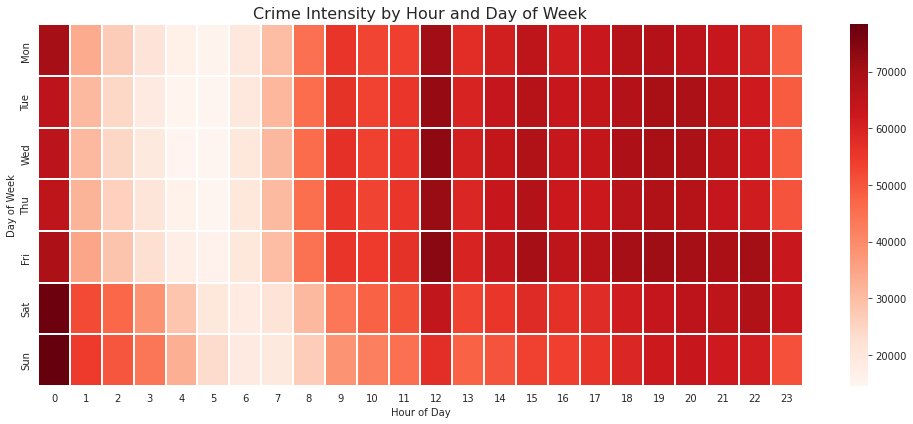

In [6]:
pivot = pdf.pivot(
    index="weekday",
    columns="hour",
    values="crime_count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap="Reds",
    linewidths=0.3
)

plt.title("Crime Intensity by Hour and Day of Week", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()

plt.savefig(
    "/home/jovyan/notebooks/outputs/temporal_heatmap_hour_weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [7]:
spark.stop()